# 02a - Bias Detection with Fairlearn

Fairlearn approaches measurement with **one central abstraction and a thin
convenience layer on top of it**:

* `MetricFrame` - takes *any* callable with a `(y_true, y_pred)` signature and
  evaluates it once per subgroup. Nothing about it is fairness-specific; it is
  a disaggregation engine.
* Scalar helpers such as `demographic_parity_difference` - pre-composed
  shortcuts for the handful of parity definitions people ask for most often.
* `make_derived_metric` - the escape hatch that turns any metric of yours into
  a group-aggregated one.

That design has a direct consequence for this comparison: Fairlearn can measure
**any** performance metric across groups, including metrics it has never heard
of, but it only ships **group** fairness definitions. Individual and
distributional fairness (consistency, Theil index) have no equivalent here -
see `03_aif360/03a_aif360_detection.ipynb` for that side.

This notebook works through seven layers, from the most generic to the most
specialised.

In [1]:
# --- Setup -----------------------------------------------------------------
import pathlib
import sys
import warnings

sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

import common
from fairlearn.metrics import (
    MetricFrame,
    count,
    demographic_parity_difference,
    demographic_parity_ratio,
    equal_opportunity_difference,
    equal_opportunity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio,
    false_negative_rate,
    false_positive_rate,
    false_positive_rate_difference,
    make_derived_metric,
    mean_prediction,
    selection_rate,
    selection_rate_difference,
    true_positive_rate,
    true_positive_rate_difference,
)

warnings.filterwarnings("ignore", category=FutureWarning)
common.set_plot_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

common.FAIRLEARN_RESULTS.mkdir(parents=True, exist_ok=True)
common.FAIRLEARN_FIGURES.mkdir(parents=True, exist_ok=True)

common.environment_report()

,component,version
0,python,3.10.5
1,platform,Windows 10
2,executable,D:\.pyenv\pyenv-win\pyenv-win\versions\3.10.5\...
3,seed,42
4,numpy,2.2.5
5,pandas,2.2.3
6,scipy,1.15.2
7,sklearn,1.6.1
8,matplotlib,3.10.1
9,fairlearn,0.14.0


## The model under audit

The baseline is defined once, in `common.make_baseline_model()`, and the AIF360
notebook trains the identical object on the identical split. Every number in
this notebook and every number in the AIF360 notebook therefore describes the
*same* set of predictions - any difference between the two notebooks is a
difference between the libraries, not between the models.

The model never sees `sex`, `age_group`, `race` or `age`. It is an "unaware"
classifier, which is what most teams actually ship.

In [2]:
# --- Train the shared baseline --------------------------------------------
train, test = common.load_data()
ground_truth = common.load_ground_truth()

X_train, y_train = common.split_xy(train)
X_test, y_test = common.split_xy(test)

model = common.make_baseline_model()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)[:, 1]

# Persist the predictions so the comparison notebook can assert that both
# libraries were pointed at byte-identical inputs.
pd.DataFrame(
    {"y_true": y_test, "y_pred": y_pred, "y_score": y_score}
).to_csv(common.FAIRLEARN_RESULTS / "baseline_test_predictions.csv", index=False)

print(f"train rows: {len(train):,}   test rows: {len(test):,}")
print(f"overall accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"overall AUC      : {roc_auc_score(y_test, y_score):.4f}")
print(f"overall selection: {y_pred.mean():.4f}")

train rows: 10,273   test rows: 4,404
overall accuracy : 0.7554
overall AUC      : 0.8392
overall selection: 0.4326


## Layer 1 - Generic performance metrics, disaggregated

This is the part of Fairlearn that is *not* about fairness at all. `MetricFrame`
accepts a dict of ordinary scikit-learn metrics and reports each one per group.

The strength here is that the metric set is completely open. Anything with a
`(y_true, y_pred)` signature works, including your own business KPI. AIF360's
`ClassificationMetric` has a fixed, closed catalogue by comparison.

`count` is included deliberately: it is how mechanism B4 (representation bias)
becomes visible, and it is the context you need before trusting any of the
other numbers for `GroupC`.

In [3]:
# --- Layer 1: any sklearn metric, per group -------------------------------
# Note these are plain sklearn callables plus a few rate helpers; nothing in
# this dict is fairness-specific.
performance_metrics = {
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "precision": precision_score,
    "recall": recall_score,
    "f1": f1_score,
    "selection_rate": selection_rate,
    "true_positive_rate": true_positive_rate,
    "false_positive_rate": false_positive_rate,
    "false_negative_rate": false_negative_rate,
    "count": count,
}

mf_sex = MetricFrame(
    metrics=performance_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=test["sex"],
)

print("--- overall (ungrouped) ---")
display(mf_sex.overall.to_frame("overall").T.round(4))
print("--- by group ---")
display(mf_sex.by_group.round(4))

--- overall (ungrouped) ---


,accuracy,balanced_accuracy,precision,recall,f1,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,count
overall,0.7554,0.751,0.7297,0.7121,0.7208,0.4326,0.7121,0.21,0.2879,4404.0


--- by group ---


,accuracy,balanced_accuracy,precision,recall,f1,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,count
sex,,,,,,,,,,
Female,0.7319,0.6893,0.5806,0.5717,0.5761,0.3138,0.5717,0.1931,0.4283,1839.0
Male,0.7723,0.7723,0.7944,0.7723,0.7832,0.5177,0.7723,0.2277,0.2277,2565.0


### The four aggregation methods

Having a table per group is not yet a fairness number. `MetricFrame` offers
four ways to collapse it, and the choice matters:

| method | question it answers |
|--------|--------------------|
| `.difference('between_groups')` | how far apart are the best and worst groups? |
| `.difference('to_overall')` | how far is each group from the population value? |
| `.ratio('between_groups')` | worst/best as a proportion - the "80% rule" view |
| `.group_min()` / `.group_max()` | what does the worst-off group experience? |

`group_min` is worth dwelling on: a regulator usually cares about the floor,
not the spread. Two models with identical `difference` can have very different
floors.

In [4]:
# --- Layer 1b: the aggregation API ----------------------------------------
aggregations = pd.DataFrame(
    {
        "difference_between_groups": mf_sex.difference(method="between_groups"),
        "difference_to_overall": mf_sex.difference(method="to_overall"),
        "ratio_between_groups": mf_sex.ratio(method="between_groups"),
        "group_min": mf_sex.group_min(),
        "group_max": mf_sex.group_max(),
    }
).round(4)

display(aggregations)

print("Reading the selection_rate row:")
sr = mf_sex.by_group["selection_rate"]
print(f"  worst group ({sr.idxmin()}): {sr.min():.4f}")
print(f"  best group  ({sr.idxmax()}): {sr.max():.4f}")
print(f"  difference: {sr.max() - sr.min():.4f}   ratio: {sr.min() / sr.max():.4f}")
print()
print("The 80% rule (US EEOC four-fifths guideline) asks whether the ratio")
print(f"clears 0.80. Here it is {sr.min() / sr.max():.3f} -> the model would fail it.")

,difference_between_groups,difference_to_overall,ratio_between_groups,group_min,group_max
accuracy,0.0404,0.0235,0.9477,0.7319,0.7723
balanced_accuracy,0.0831,0.0618,0.8925,0.6893,0.7723
precision,0.2138,0.1491,0.7308,0.5806,0.7944
recall,0.2007,0.1404,0.7402,0.5717,0.7723
f1,0.2071,0.1447,0.7355,0.5761,0.7832
selection_rate,0.2040,0.1188,0.6060,0.3138,0.5177
true_positive_rate,0.2007,0.1404,0.7402,0.5717,0.7723
false_positive_rate,0.0346,0.0177,0.8482,0.1931,0.2277
false_negative_rate,0.2007,0.1404,0.5315,0.2277,0.4283
count,726.0000,2565.0000,0.7170,1839.0000,2565.0000


Reading the selection_rate row:
  worst group (Female): 0.3138
  best group  (Male): 0.5177
  difference: 0.2040   ratio: 0.6060

The 80% rule (US EEOC four-fifths guideline) asks whether the ratio
clears 0.80. Here it is 0.606 -> the model would fail it.


## Layer 2 - Score-based metrics

`MetricFrame` does not require hard labels. Passing the predicted probability
as `y_pred` lets threshold-independent metrics be disaggregated too.

This distinguishes two very different failure modes:

* a **ranking** failure - the model orders one group worse than another
  (per-group AUC differs), which here is the fingerprint of mechanism B2;
* a **threshold** failure - the ranking is fine but one shared cut-off lands in
  a different place on each group's score distribution.

Mitigation strategies for the two are not interchangeable, so it is worth
knowing which one you have before reaching for an algorithm.

In [5]:
# --- Layer 2: metrics that consume scores ---------------------------------
score_metrics = {
    "roc_auc": roc_auc_score,
    "log_loss": log_loss,
    "mean_predicted_score": mean_prediction,
}

mf_scores = MetricFrame(
    metrics=score_metrics,
    y_true=y_test,
    y_pred=y_score,
    sensitive_features=test["sex"],
)

score_table = mf_scores.by_group.round(4)
score_table.loc["difference"] = mf_scores.difference().round(4)
display(score_table)

print("A per-group AUC gap means the score itself is less informative for one")
print("group - exactly what mechanism B2 (noisier credit_score) was built to")
print("produce. No decision threshold can repair that.")

,roc_auc,log_loss,mean_predicted_score
sex,,,
Female,0.7996,0.5059,0.3617
Male,0.8510,0.4833,0.5084
difference,0.0513,0.0227,0.1467


A per-group AUC gap means the score itself is less informative for one
group - exactly what mechanism B2 (noisier credit_score) was built to
produce. No decision threshold can repair that.


## Layer 3 - The dedicated fairness scalars

These are the functions people reach for first. Each one collapses the whole
problem to a single number, and each encodes a different normative claim:

| function | constraint | informal reading |
|----------|-----------|------------------|
| `demographic_parity_difference` | P(Yhat=1 \| A) equal | equal approval rates, full stop |
| `demographic_parity_ratio` | same, as a ratio | the four-fifths rule |
| `equal_opportunity_difference` | TPR equal | among people who *should* be approved, equal chance |
| `equalized_odds_difference` | TPR **and** FPR equal | equal error profile on both sides |
| `false_positive_rate_difference` | FPR equal | equal rate of undeserved approvals |
| `selection_rate_difference` | same as DP difference | alias, no `y_true` needed |

Demographic parity and equalized odds are mathematically incompatible whenever
base rates genuinely differ across groups, so this table is not a checklist to
zero out - it is a menu you have to choose from.

In [6]:
# --- Layer 3: fairness scalars across all sensitive attributes ------------
FAIRNESS_SCALARS = {
    "demographic_parity_difference": demographic_parity_difference,
    "demographic_parity_ratio": demographic_parity_ratio,
    "equalized_odds_difference": equalized_odds_difference,
    "equalized_odds_ratio": equalized_odds_ratio,
    "equal_opportunity_difference": equal_opportunity_difference,
    "equal_opportunity_ratio": equal_opportunity_ratio,
    "true_positive_rate_difference": true_positive_rate_difference,
    "false_positive_rate_difference": false_positive_rate_difference,
    "selection_rate_difference": selection_rate_difference,
}

rows = []
for attribute in common.SENSITIVE_COLUMNS:
    row = {"sensitive_attribute": attribute, "n_groups": test[attribute].nunique()}
    for name, function in FAIRNESS_SCALARS.items():
        row[name] = function(
            y_test, y_pred, sensitive_features=test[attribute]
        )
    rows.append(row)

fairness_scalars = pd.DataFrame(rows).set_index("sensitive_attribute").round(4)
fairness_scalars.to_csv(common.FAIRLEARN_RESULTS / "fairness_scalars.csv")
display(fairness_scalars.T)

sensitive_attribute,sex,age_group,race
n_groups,2.0000,2.0000,3.0000
demographic_parity_difference,0.2040,0.0440,0.1084
demographic_parity_ratio,0.6060,0.9002,0.7696
equalized_odds_difference,0.2007,0.0209,0.0687
equalized_odds_ratio,0.7402,0.9077,0.9064
equal_opportunity_difference,0.2007,0.0155,0.0687
equal_opportunity_ratio,0.7402,0.9784,0.9064
true_positive_rate_difference,0.2007,0.0155,0.0687
false_positive_rate_difference,0.0346,0.0209,0.0203
selection_rate_difference,0.2040,0.0440,0.1084


### `agg` on equalized odds - a detail worth knowing

`equalized_odds_difference` reports the **worst** of the TPR gap and the FPR gap
by default (`agg="worst_case"`). Switching to `agg="mean"` averages them
instead. The two can disagree substantially when a model is unfair on only one
of the two error types, which is common.

In [7]:
# --- The worst_case vs mean aggregation ----------------------------------
agg_comparison = []
for attribute in common.SENSITIVE_COLUMNS:
    A = test[attribute]
    agg_comparison.append(
        {
            "sensitive_attribute": attribute,
            "tpr_difference": true_positive_rate_difference(y_test, y_pred, sensitive_features=A),
            "fpr_difference": false_positive_rate_difference(y_test, y_pred, sensitive_features=A),
            "eq_odds_worst_case": equalized_odds_difference(y_test, y_pred, sensitive_features=A, agg="worst_case"),
            "eq_odds_mean": equalized_odds_difference(y_test, y_pred, sensitive_features=A, agg="mean"),
        }
    )
display(pd.DataFrame(agg_comparison).set_index("sensitive_attribute").round(4))

,tpr_difference,fpr_difference,eq_odds_worst_case,eq_odds_mean
sensitive_attribute,,,,
sex,0.2007,0.0346,0.2007,0.1176
age_group,0.0155,0.0209,0.0209,0.0182
race,0.0687,0.0203,0.0687,0.0445


## Cross-checking against the injected ground truth

This is the step no real dataset allows. `ground_truth.json` records both the
disparity that mechanism B1 wrote into the labels and the residual disparity
that survives in the counterfactually fair label.

Three quantities to compare:

1. **fair SPD** - the gap present even without discrimination (upstream
   inequality in income/education, and the legitimate age horizon effect).
2. **observed SPD** - the gap in the recorded labels, i.e. `fair + B1`.
3. **model DP difference** - what Fairlearn measures on the predictions.

If (3) exceeds (2), the model has *amplified* the historical bias rather than
merely inheriting it.

In [8]:
# --- Measured vs injected -------------------------------------------------
validation_rows = []
for attribute in common.SENSITIVE_COLUMNS:
    injected = ground_truth["realised_disparities"][attribute]
    spec = common.SENSITIVE_SPECS[attribute]
    privileged = spec["privileged"]
    unprivileged = spec["unprivileged"]
    unprivileged_keys = unprivileged if isinstance(unprivileged, list) else [unprivileged]

    # Signed model gap: unprivileged minus privileged selection rate, so it is
    # directly comparable with the signed SPD stored in ground_truth.json.
    frame = MetricFrame(
        metrics=selection_rate,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=test[attribute],
    ).by_group
    model_gap = float(np.mean([frame[k] for k in unprivileged_keys]) - frame[privileged])

    validation_rows.append(
        {
            "sensitive_attribute": attribute,
            "fair_SPD_no_discrimination": injected["fair_statistical_parity_difference"],
            "observed_SPD_in_labels": injected["observed_statistical_parity_difference"],
            "model_SPD_in_predictions": round(model_gap, 4),
            "amplification": round(
                model_gap - injected["observed_statistical_parity_difference"], 4
            ),
        }
    )

validation = pd.DataFrame(validation_rows).set_index("sensitive_attribute")
validation.to_csv(common.FAIRLEARN_RESULTS / "measured_vs_injected.csv")
display(validation)

print("Negative values mean the unprivileged group is worse off.")
print("A negative 'amplification' means the model made the historical gap wider")
print("than it already was in the training labels.")

,fair_SPD_no_discrimination,observed_SPD_in_labels,model_SPD_in_predictions,amplification
sensitive_attribute,,,,
sex,-0.1337,-0.2135,-0.2040,0.0095
age_group,-0.0478,-0.1022,-0.0440,0.0582
race,-0.0646,-0.1216,-0.0989,0.0227


Negative values mean the unprivileged group is worse off.
A negative 'amplification' means the model made the historical gap wider
than it already was in the training labels.


## Layer 4 - Derived metrics: making any metric a fairness metric

`make_derived_metric` is the most under-appreciated part of the API. It takes
an arbitrary metric and a transform (`difference`, `ratio`, `group_min`,
`group_max`) and returns a scalar function with the usual signature.

This matters in practice because the metric a business actually cares about is
almost never one of the nine canonical parity definitions. Below, a cost
function - a false denial hurts five times more than a bad approval - is turned
into a group-aware metric that Fairlearn has never seen before.

AIF360 has no equivalent: its metric catalogue is fixed, and extending it means
subclassing `ClassificationMetric`.

In [9]:
# --- Layer 4: pre-built and custom derived metrics -------------------------
# Fairlearn ships a number of these already built.
from fairlearn.metrics import (
    accuracy_score_difference,
    accuracy_score_group_min,
    f1_score_group_min,
    recall_score_group_min,
)


def expected_business_cost(y_true, y_pred, fn_cost=5.0, fp_cost=1.0):
    # A denied-but-qualified applicant (false negative) is a lost customer and
    # a compliance risk; an approved-but-unqualified one is a credit loss.
    # The asymmetry is what makes this different from plain accuracy.
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    false_negatives = np.sum((y_true == 1) & (y_pred == 0))
    false_positives = np.sum((y_true == 0) & (y_pred == 1))
    return (fn_cost * false_negatives + fp_cost * false_positives) / len(y_true)


# Turn the custom metric into three group-aware variants.
cost_group_max = make_derived_metric(metric=expected_business_cost, transform="group_max")
cost_difference = make_derived_metric(metric=expected_business_cost, transform="difference")
cost_ratio = make_derived_metric(metric=expected_business_cost, transform="ratio")

derived_rows = []
for attribute in common.SENSITIVE_COLUMNS:
    A = test[attribute]
    derived_rows.append(
        {
            "sensitive_attribute": attribute,
            "accuracy_difference": accuracy_score_difference(y_test, y_pred, sensitive_features=A),
            "accuracy_group_min": accuracy_score_group_min(y_test, y_pred, sensitive_features=A),
            "recall_group_min": recall_score_group_min(y_test, y_pred, sensitive_features=A),
            "f1_group_min": f1_score_group_min(y_test, y_pred, sensitive_features=A),
            "custom_cost_group_max": cost_group_max(y_test, y_pred, sensitive_features=A),
            "custom_cost_difference": cost_difference(y_test, y_pred, sensitive_features=A),
            "custom_cost_ratio": cost_ratio(y_test, y_pred, sensitive_features=A),
        }
    )

derived_metrics = pd.DataFrame(derived_rows).set_index("sensitive_attribute").round(4)
derived_metrics.to_csv(common.FAIRLEARN_RESULTS / "derived_metrics.csv")
display(derived_metrics)

print(f"Population-wide cost: {expected_business_cost(y_test, y_pred):.4f}")
print("The group_max column shows what the worst-served group actually pays,")
print("which the population number hides completely.")

,accuracy_difference,accuracy_group_min,recall_group_min,f1_group_min,custom_cost_group_max,custom_cost_difference,custom_cost_ratio
sensitive_attribute,,,,,,,
sex,0.0404,0.7319,0.5717,0.5761,0.8140,0.1014,0.8755
age_group,0.0108,0.7467,0.6990,0.6656,0.7706,0.0831,0.8922
race,0.0121,0.7470,0.6659,0.6566,0.7675,0.0598,0.9221


Population-wide cost: 0.7550
The group_max column shows what the worst-served group actually pays,
which the population number hides completely.


## Layer 5 - Intersectional analysis

Passing several columns as `sensitive_features` makes `MetricFrame` evaluate
every observed combination. Mechanism B1 composed its flip probabilities
multiplicatively, so the joint groups are *not* predictable from the marginals -
which is the entire argument for looking at intersections.

The `count` column is essential here. Some cells are small, and a selection
rate computed on 200 rows is not the same kind of evidence as one computed on
1,500.

In [10]:
# --- Layer 5: intersectional metric frame ---------------------------------
mf_intersectional = MetricFrame(
    metrics={
        "selection_rate": selection_rate,
        "true_positive_rate": true_positive_rate,
        "false_positive_rate": false_positive_rate,
        "accuracy": accuracy_score,
        "count": count,
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=test[["sex", "race"]],
)

intersectional = mf_intersectional.by_group.round(4)
intersectional.to_csv(common.FAIRLEARN_RESULTS / "intersectional_sex_race.csv")
display(intersectional)

print(f"worst intersectional selection rate: {mf_intersectional.group_min()['selection_rate']:.4f}")
print(f"best  intersectional selection rate: {mf_intersectional.group_max()['selection_rate']:.4f}")
print(f"intersectional DP difference       : {mf_intersectional.difference()['selection_rate']:.4f}")
print()
print("Compare with the single-axis numbers:")
print(f"  sex alone : {fairness_scalars.loc['sex', 'demographic_parity_difference']:.4f}")
print(f"  race alone: {fairness_scalars.loc['race', 'demographic_parity_difference']:.4f}")
print("The joint gap is larger than either marginal gap - the subgroup at the")
print("intersection is worse off than a marginal analysis would ever reveal.")

selection_rate  true_positive_rate  false_positive_rate  accuracy   count
sex    race                                                                             
Female GroupA          0.3433              0.5953               0.2089    0.7230  1101.0
       GroupB          0.2771              0.5217               0.1833    0.7349   498.0
       GroupC          0.2542              0.5385               0.1486    0.7667   240.0
Male   GroupA          0.5593              0.7926               0.2272    0.7844  1568.0
       GroupB          0.4571              0.7293               0.2210    0.7559   676.0
       GroupC          0.4424              0.7328               0.2421    0.7477   321.0

worst intersectional selection rate: 0.2542
best  intersectional selection rate: 0.5593
intersectional DP difference       : 0.3051

Compare with the single-axis numbers:
  sex alone : 0.2040
  race alone: 0.1084
The joint gap is larger than either marginal gap - the subgroup at the
intersection is worse off than a marginal analysis would ever reveal.


In [11]:
# --- Three-way intersection: sex x age_group x race -----------------------
# Fairlearn imposes no limit on the number of sensitive columns, but the cells
# get small fast. This is where `count` stops being optional.
mf_three_way = MetricFrame(
    metrics={"selection_rate": selection_rate, "count": count},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=test[["sex", "age_group", "race"]],
)

three_way = mf_three_way.by_group.round(4).sort_values("selection_rate")
display(three_way)

small_cells = three_way[three_way["count"] < 100]
print(f"{len(small_cells)} of {len(three_way)} cells have fewer than 100 rows.")
print("Their metric values carry very wide uncertainty - quantified in Layer 7.")

selection_rate   count
sex    age_group race                          
Female 55_plus   GroupC          0.2381    42.0
                 GroupB          0.2449    98.0
       under_55  GroupC          0.2576   198.0
                 GroupB          0.2850   400.0
       55_plus   GroupA          0.3045   220.0
       under_55  GroupA          0.3530   881.0
Male   55_plus   GroupC          0.3559    59.0
                 GroupB          0.4080   125.0
       under_55  GroupC          0.4618   262.0
                 GroupB          0.4682   551.0
       55_plus   GroupA          0.5474   285.0
       under_55  GroupA          0.5620  1283.0

3 of 12 cells have fewer than 100 rows.
Their metric values carry very wide uncertainty - quantified in Layer 7.


## Layer 6 - Conditional metrics via `control_features`

This addresses a real objection: *"of course approval rates differ, the groups
applied for different loan sizes."*

AIF360 does ship one conditional metric,
`aif360.sklearn.metrics.conditional_demographic_disparity`. The difference is
generality: that function is a single hard-coded definition, whereas
`control_features` conditions *any* metric in the frame on *any* stratifier you
choose - which is what makes the contrast in the second cell below possible.

`control_features` stratifies first and compares within strata. If the
disparity vanishes inside every stratum, the raw gap was composition; if it
persists, the control variable does not explain it.

This is **conditional demographic parity** (Kamiran et al.), and it is the
formal way to argue about legitimate versus illegitimate explanations of a gap.
It is also how the deliberately-injected legitimate age effect (the repayment
horizon term) can be told apart from injected ageism.

In [12]:
# --- Layer 6: conditional demographic parity ------------------------------
# Stratify on the requested loan size, an unambiguously legitimate factor.
loan_band = pd.qcut(
    test["loan_amount"], 3, labels=["small_loan", "medium_loan", "large_loan"]
).rename("loan_band")

mf_conditional = MetricFrame(
    metrics={"selection_rate": selection_rate, "count": count},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=test["sex"],
    control_features=loan_band,
)

display(mf_conditional.by_group.round(4))

conditional_gap = mf_conditional.difference()["selection_rate"]
unconditional_gap = fairness_scalars.loc["sex", "demographic_parity_difference"]

conditional_summary = pd.DataFrame(
    {
        "unconditional_DP_difference": [unconditional_gap],
        "conditional_DP_difference_max_stratum": [conditional_gap.max()],
        "conditional_DP_difference_min_stratum": [conditional_gap.min()],
        "explained_by_loan_size": [unconditional_gap - conditional_gap.mean()],
    }
).round(4)
conditional_summary.to_csv(common.FAIRLEARN_RESULTS / "conditional_parity.csv", index=False)
display(conditional_summary)

print("The gap survives inside every loan band, so differing loan sizes do not")
print("explain it. Controlling changed the number only slightly.")

selection_rate   count
loan_band   sex                           
large_loan  Female          0.4411   433.0
            Male            0.6370  1022.0
medium_loan Female          0.3648   603.0
            Male            0.4977   854.0
small_loan  Female          0.2067   803.0
            Male            0.3657   689.0

,unconditional_DP_difference,conditional_DP_difference_max_stratum,conditional_DP_difference_min_stratum,explained_by_loan_size
0,0.204,0.1959,0.1328,0.0414


The gap survives inside every loan band, so differing loan sizes do not
explain it. Controlling changed the number only slightly.


In [13]:
# --- Controlling for a genuinely explanatory variable ---------------------
# Contrast: stratify on predicted risk instead. Because the model's score is
# itself contaminated by the proxies, conditioning on it makes the disparity
# largely disappear - a textbook example of why "controlling for everything"
# is not a fairness argument. Conditioning on a variable that already encodes
# the sensitive attribute defines the bias away rather than removing it.
# qcut on a plain array returns a Categorical, so wrap it back into a Series.
risk_band = pd.Series(
    pd.qcut(y_score, 4, labels=["q1_low", "q2", "q3", "q4_high"]),
    index=test.index,
    name="risk_band",
)

mf_risk = MetricFrame(
    metrics={"selection_rate": selection_rate, "count": count},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=test["sex"],
    control_features=risk_band,
)
display(mf_risk.by_group.round(4))
print("DP difference within each predicted-risk band:")
display(mf_risk.difference()["selection_rate"].round(4))

selection_rate  count
risk_band sex                          
q1_low    Female          0.0000  642.0
          Male            0.0000  459.0
q2        Female          0.0000  508.0
          Male            0.0000  593.0
q3        Female          0.7314  417.0
          Male            0.7295  684.0
q4_high   Female          1.0000  272.0
          Male            1.0000  829.0

DP difference within each predicted-risk band:


risk_band
q1_low     0.0000
q2         0.0000
q3         0.0019
q4_high    0.0000
Name: selection_rate, dtype: float64

## Layer 7 - Uncertainty: is the disparity statistically real?

Since v0.10 `MetricFrame` can bootstrap every quantity it computes. Pass
`n_boot` and `ci_quantiles` and the frame gains `by_group_ci`, `difference_ci`
and `overall_ci`.

This is a genuine capability gap in the comparison: **AIF360 reports point
estimates only**. On a small subgroup - and mechanism B4 made sure some
subgroups are small - a point estimate on its own can be badly misleading.

In [14]:
# --- Layer 7: bootstrap confidence intervals ------------------------------
CI_QUANTILES = [0.025, 0.5, 0.975]

mf_boot = MetricFrame(
    metrics={
        "selection_rate": selection_rate,
        "true_positive_rate": true_positive_rate,
        "accuracy": accuracy_score,
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=test["race"],
    n_boot=1000,
    ci_quantiles=CI_QUANTILES,
    random_state=common.SEED,
)

lower, median, upper = mf_boot.by_group_ci
ci_table = pd.concat(
    {"lower_2.5%": lower, "median": median, "upper_97.5%": upper}, axis=1
).round(4)
ci_table.to_csv(common.FAIRLEARN_RESULTS / "bootstrap_ci_race.csv")
display(ci_table)

diff_lower, diff_median, diff_upper = mf_boot.difference_ci()
print("95% CI for the between-group DIFFERENCE:")
for metric in mf_boot.by_group.columns:
    low, high = diff_lower[metric], diff_upper[metric]
    verdict = "significant" if low > 0 else "NOT significant"
    print(f"  {metric:22s}: [{low:.4f}, {high:.4f}]  -> {verdict}")

lower_2.5%                                     median                                upper_97.5%                            
       selection_rate true_positive_rate accuracy selection_rate true_positive_rate accuracy selection_rate true_positive_rate accuracy
race                                                                                                                                   
GroupA         0.4522             0.7121   0.7431         0.4707             0.7345   0.7587         0.4882             0.7568   0.7742
GroupB         0.3536             0.6225   0.7218         0.3808             0.6667   0.7475         0.4084             0.7077   0.7717
GroupC         0.3218             0.6011   0.7179         0.3616             0.6667   0.7553         0.4015             0.7366   0.7891

95% CI for the between-group DIFFERENCE:
  selection_rate        : [0.0737, 0.1510]  -> significant
  true_positive_rate    : [0.0374, 0.1386]  -> significant
  accuracy              : [0.0043, 0.0581]  -> significant


## Visualisations

Five figures, saved to `figures/`.

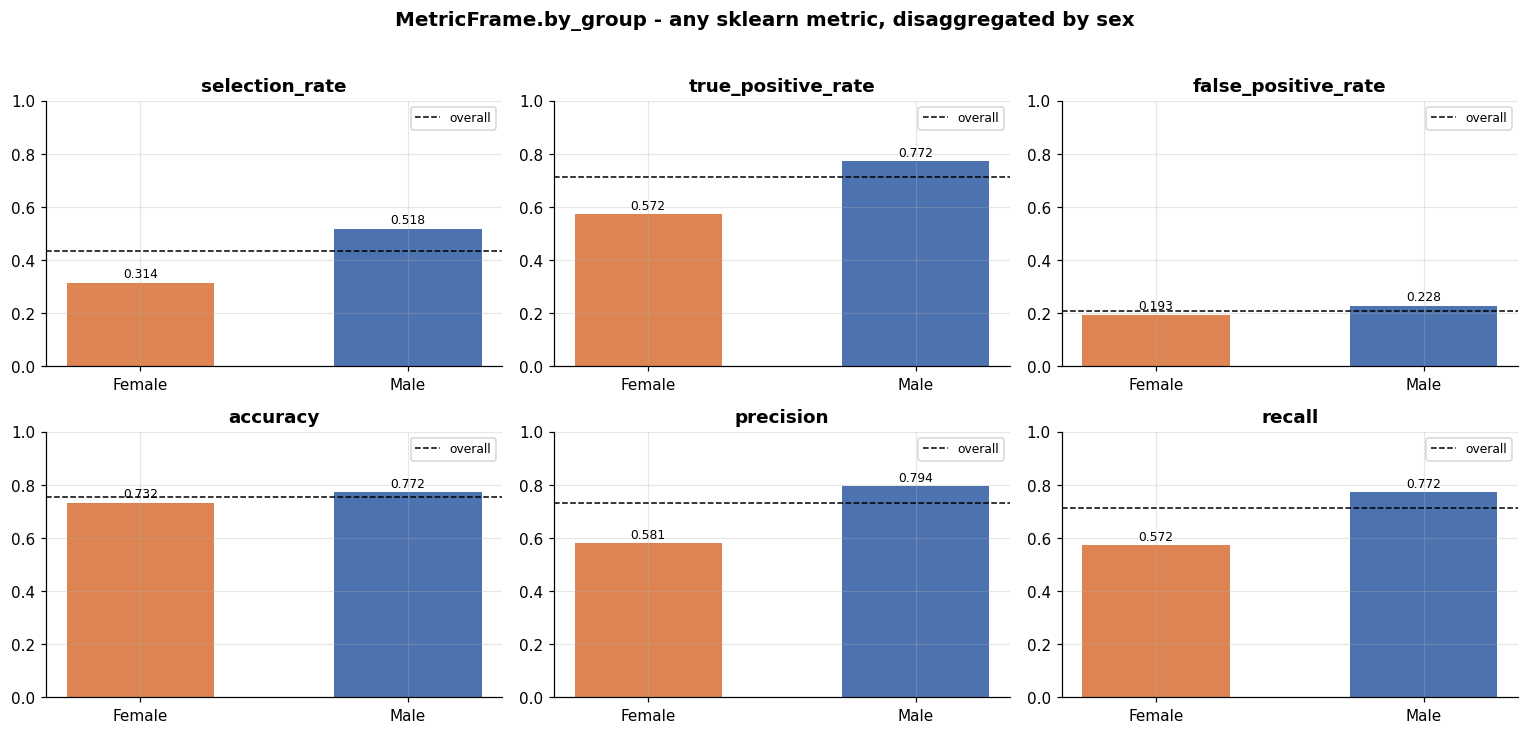

In [15]:
# --- Figure 1: per-group performance --------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5))
plot_metrics = [
    "selection_rate", "true_positive_rate", "false_positive_rate",
    "accuracy", "precision", "recall",
]

for ax, metric in zip(axes.ravel(), plot_metrics):
    values = mf_sex.by_group[metric]
    colours = [common.GROUP_PALETTE.get(g, "#888888") for g in values.index]
    ax.bar(values.index.astype(str), values.values, color=colours, width=0.55)
    ax.axhline(mf_sex.overall[metric], ls="--", c="black", lw=1, label="overall")
    ax.set_title(metric)
    ax.set_ylim(0, max(1.0, values.max() * 1.2))
    ax.legend(fontsize=8)
    for i, v in enumerate(values.values):
        ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)

fig.suptitle("MetricFrame.by_group - any sklearn metric, disaggregated by sex",
             y=1.02, fontsize=13, fontweight="bold")
fig.tight_layout()
common.savefig(fig, common.FAIRLEARN_FIGURES, "fl_fig1_by_group_sex.png")
plt.show()

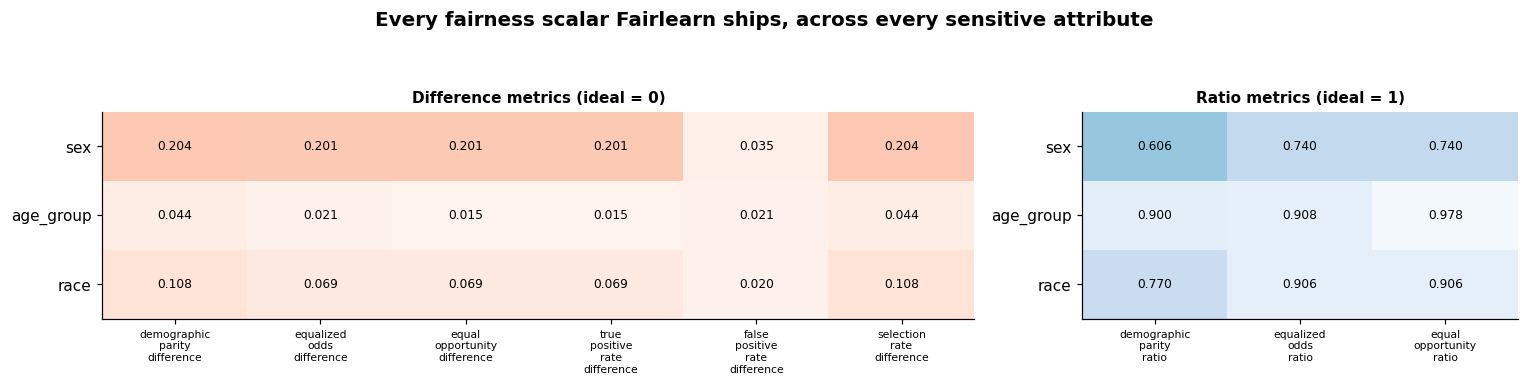

In [16]:
# --- Figure 2: disparity heatmap ------------------------------------------
# Rows are sensitive attributes, columns are fairness definitions. Difference
# metrics and ratio metrics are shown on separate panels because 0 is the ideal
# for one and 1 for the other.
difference_columns = [c for c in fairness_scalars.columns if c.endswith("_difference")]
ratio_columns = [c for c in fairness_scalars.columns if c.endswith("_ratio")]

fig, axes = plt.subplots(1, 2, figsize=(14, 3.2),
                         gridspec_kw={"width_ratios": [len(difference_columns), len(ratio_columns)]})

for ax, columns, cmap, ideal, title in [
    (axes[0], difference_columns, "Reds", 0.0, "Difference metrics (ideal = 0)"),
    (axes[1], ratio_columns, "Blues_r", 1.0, "Ratio metrics (ideal = 1)"),
]:
    data = fairness_scalars[columns]
    image = ax.imshow(data.values, cmap=cmap, aspect="auto",
                      vmin=min(0, data.values.min()), vmax=max(1, data.values.max()))
    ax.set_xticks(range(len(columns)))
    ax.set_xticklabels([c.replace("_", "\n") for c in columns], fontsize=7)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    ax.set_title(f"{title}", fontsize=10)
    ax.grid(False)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data.values[i, j]:.3f}", ha="center", va="center", fontsize=8)

fig.suptitle("Every fairness scalar Fairlearn ships, across every sensitive attribute",
             y=1.08, fontsize=13, fontweight="bold")
fig.tight_layout()
common.savefig(fig, common.FAIRLEARN_FIGURES, "fl_fig2_disparity_heatmap.png")
plt.show()

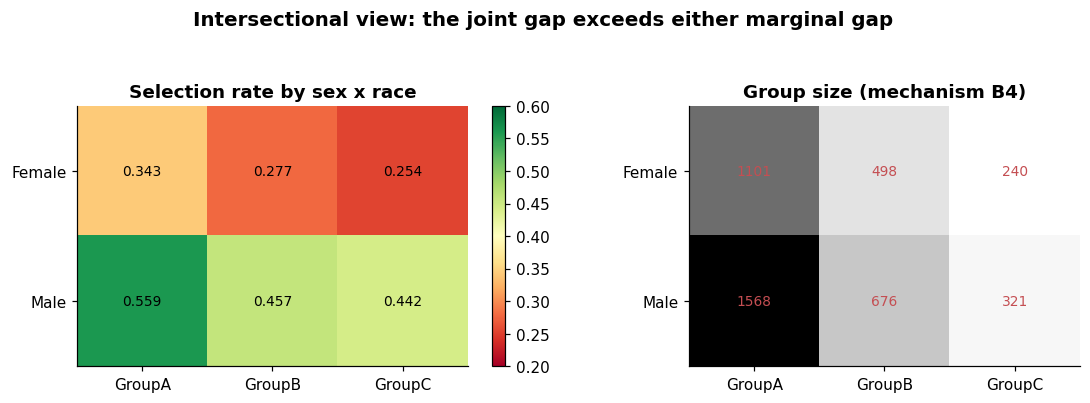

In [17]:
# --- Figure 3: intersectional heatmap -------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

pivot_rate = intersectional["selection_rate"].unstack()
pivot_count = intersectional["count"].unstack()

image = axes[0].imshow(pivot_rate.values, cmap="RdYlGn", vmin=0.2, vmax=0.6)
axes[0].set_xticks(range(len(pivot_rate.columns)))
axes[0].set_xticklabels(pivot_rate.columns)
axes[0].set_yticks(range(len(pivot_rate.index)))
axes[0].set_yticklabels(pivot_rate.index)
axes[0].set_title("Selection rate by sex x race")
axes[0].grid(False)
for i in range(pivot_rate.shape[0]):
    for j in range(pivot_rate.shape[1]):
        axes[0].text(j, i, f"{pivot_rate.values[i, j]:.3f}", ha="center", va="center", fontsize=9)
fig.colorbar(image, ax=axes[0], fraction=0.046)

axes[1].imshow(pivot_count.values, cmap="Greys")
axes[1].set_xticks(range(len(pivot_count.columns)))
axes[1].set_xticklabels(pivot_count.columns)
axes[1].set_yticks(range(len(pivot_count.index)))
axes[1].set_yticklabels(pivot_count.index)
axes[1].set_title("Group size (mechanism B4)")
axes[1].grid(False)
for i in range(pivot_count.shape[0]):
    for j in range(pivot_count.shape[1]):
        axes[1].text(j, i, f"{int(pivot_count.values[i, j])}", ha="center", va="center",
                     fontsize=9, color="#C44E52")

fig.suptitle("Intersectional view: the joint gap exceeds either marginal gap",
             y=1.06, fontsize=13, fontweight="bold")
fig.tight_layout()
common.savefig(fig, common.FAIRLEARN_FIGURES, "fl_fig3_intersectional.png")
plt.show()

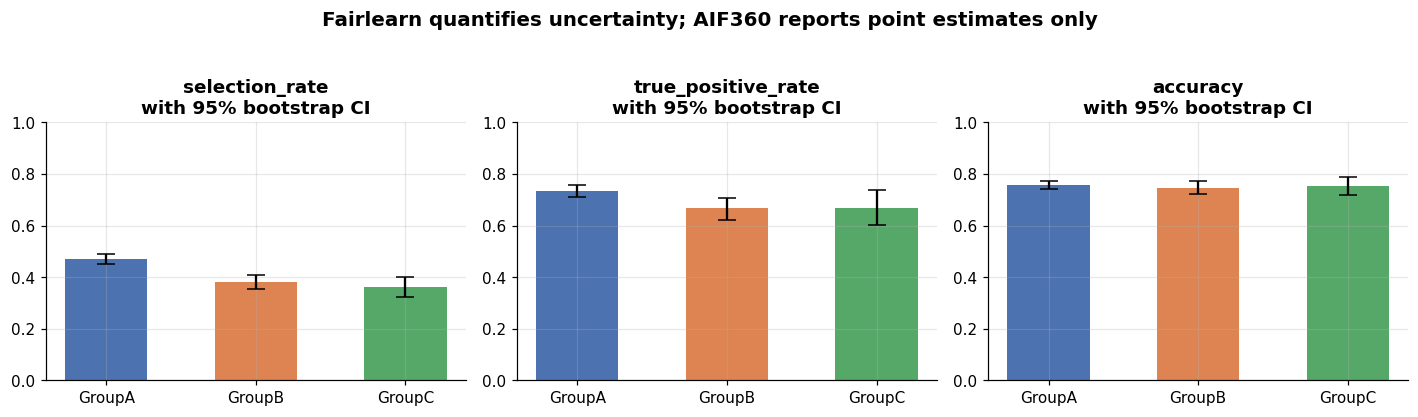

In [18]:
# --- Figure 4: bootstrap confidence intervals -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

for ax, metric in zip(axes, ["selection_rate", "true_positive_rate", "accuracy"]):
    groups = median.index.astype(str)
    centre = median[metric].values
    lower_error = centre - lower[metric].values
    upper_error = upper[metric].values - centre
    colours = [common.GROUP_PALETTE.get(g, "#888888") for g in median.index]
    ax.bar(groups, centre, color=colours, width=0.55)
    ax.errorbar(groups, centre, yerr=[lower_error, upper_error], fmt="none",
                ecolor="black", capsize=6, lw=1.5)
    ax.set_title(f"{metric}\nwith 95% bootstrap CI")
    ax.set_ylim(0, max(1.0, (upper[metric].values.max()) * 1.25))

fig.suptitle("Fairlearn quantifies uncertainty; AIF360 reports point estimates only",
             y=1.04, fontsize=13, fontweight="bold")
fig.tight_layout()
common.savefig(fig, common.FAIRLEARN_FIGURES, "fl_fig4_bootstrap_ci.png")
plt.show()

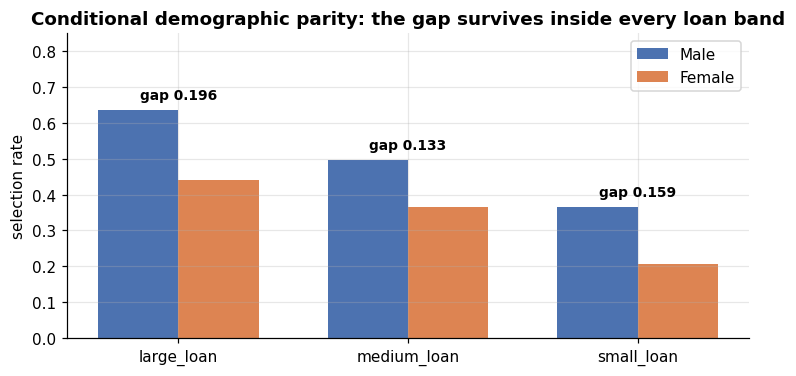

In [19]:
# --- Figure 5: conditional vs unconditional parity ------------------------
fig, ax = plt.subplots(figsize=(8, 3.6))

conditional_rates = mf_conditional.by_group["selection_rate"].unstack()
positions = np.arange(len(conditional_rates.index))
width = 0.35

ax.bar(positions - width / 2, conditional_rates["Male"], width,
       label="Male", color=common.PRIVILEGED_COLOR)
ax.bar(positions + width / 2, conditional_rates["Female"], width,
       label="Female", color=common.UNPRIVILEGED_COLOR)

for i, band in enumerate(conditional_rates.index):
    gap = conditional_rates.loc[band, "Male"] - conditional_rates.loc[band, "Female"]
    ax.text(i, max(conditional_rates.loc[band]) + 0.03, f"gap {gap:.3f}",
            ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(positions)
ax.set_xticklabels(conditional_rates.index)
ax.set_ylabel("selection rate")
ax.set_ylim(0, 0.85)
ax.set_title("Conditional demographic parity: the gap survives inside every loan band")
ax.legend()

common.savefig(fig, common.FAIRLEARN_FIGURES, "fl_fig5_conditional_parity.png")
plt.show()

## Persisting the per-group tables

In [20]:
# --- Save the by-group tables for every sensitive attribute ---------------
group_tables = []
for attribute in common.SENSITIVE_COLUMNS:
    frame = MetricFrame(
        metrics=performance_metrics,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=test[attribute],
    ).by_group.reset_index()
    frame = frame.rename(columns={attribute: "group"})
    frame.insert(0, "sensitive_attribute", attribute)
    group_tables.append(frame)

group_metrics = pd.concat(group_tables, ignore_index=True).round(4)
group_metrics.to_csv(common.FAIRLEARN_RESULTS / "group_metrics.csv", index=False)
display(group_metrics)

print("\nFiles written to", common.FAIRLEARN_RESULTS)
for path in sorted(common.FAIRLEARN_RESULTS.glob("*.csv")):
    print("  ", path.name)

,sensitive_attribute,group,accuracy,balanced_accuracy,precision,recall,f1,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,count
0,sex,Female,0.7319,0.6893,0.5806,0.5717,0.5761,0.3138,0.5717,0.1931,0.4283,1839.0
1,sex,Male,0.7723,0.7723,0.7944,0.7723,0.7832,0.5177,0.7723,0.2277,0.2277,2565.0
2,age_group,55_plus,0.7467,0.7363,0.6353,0.6990,0.6656,0.3969,0.6990,0.2264,0.3010,829.0
3,age_group,under_55,0.7575,0.7545,0.7494,0.7145,0.7315,0.4408,0.7145,0.2055,0.2855,3575.0
4,race,GroupA,0.7591,0.7585,0.7633,0.7347,0.7487,0.4702,0.7347,0.2176,0.2653,2669.0
5,race,GroupB,0.7470,0.7319,0.6734,0.6659,0.6696,0.3807,0.6659,0.2022,0.3341,1174.0
6,race,GroupC,0.7558,0.7356,0.6453,0.6684,0.6566,0.3619,0.6684,0.1973,0.3316,561.0



Files written to E:\Repo\bias mitigation\02_fairlearn\results
   baseline_test_predictions.csv
   bootstrap_ci_race.csv
   conditional_parity.csv
   derived_metrics.csv
   fairness_scalars.csv
   group_metrics.csv
   intersectional_sex_race.csv
   measured_vs_injected.csv


## What this notebook establishes

**Detected, and consistent with the injected ground truth:**

* A demographic parity difference of ~0.20 on `sex`, which is roughly **95% of
  the gap present in the training labels** (-0.204 predicted vs -0.214
  recorded). The model never saw `sex`. Unawareness bought almost nothing,
  because mechanism B3 left the information in `career_gap_months` and
  `employment_type`. The DP ratio of 0.61 would fail the four-fifths rule.
* The `age_group` axis behaves differently: the model reproduces only ~43% of
  the recorded gap. The age proxy is strong (AUC 0.988 on `employment_years`),
  but that same feature also carries genuine repayment signal, so the model
  dilutes rather than reproduces the ageism. A useful reminder that proxy
  strength alone does not predict how much bias a model will inherit.
* An equalized odds violation that a pure selection-rate fix cannot address,
  driven by the per-group AUC gap - that is B2.
* Intersectional subgroups worse off than any marginal analysis shows - B1's
  multiplicative composition.
* Small, high-variance cells in `GroupC` - B4, made visible by `count` and
  quantified by the bootstrap intervals.

**Fairlearn's functional profile for detection:**

| strength | detail |
|----------|--------|
| Open metric set | any `(y_true, y_pred)` callable works, including custom KPIs |
| Aggregation choices | 4 ways to collapse a group table, each a different question |
| Intersectionality | arbitrary number of sensitive columns, first-class |
| Conditional metrics | `control_features` conditions *any* metric on *any* stratifier; AIF360 offers only the single fixed `conditional_demographic_disparity` |
| Uncertainty | bootstrap CIs on every quantity - no AIF360 equivalent |
| Extensibility | `make_derived_metric` promotes any metric to a fairness metric |

| limitation | detail |
|------------|--------|
| Group fairness only | no individual fairness (consistency, Theil index) |
| No dataset-level API | measuring label bias before modelling requires the `y_pred=y_true` trick |
| No causal / distributional metrics | nothing comparable to AIF360's differential fairness family |

The final gap is worth spelling out, because it changes how you would use the
library: Fairlearn has no notion of auditing a *dataset*. You can fake it by
passing the labels as predictions, but there is no supported entry point that
says "score this data before I train on it". AIF360 makes that a first-class
object, which is the subject of the next notebook.

In [21]:
# --- The dataset-audit workaround -----------------------------------------
# Fairlearn has no dataset-level metric class. Passing the labels themselves as
# predictions measures bias in the DATA rather than in a model. It works, but
# it is a convention rather than an API, and metrics like accuracy become
# meaningless (they are trivially 1.0).
mf_dataset = MetricFrame(
    metrics={"base_rate": selection_rate, "count": count},
    y_true=y_test,
    y_pred=y_test,
    sensitive_features=test["sex"],
)
display(mf_dataset.by_group.round(4))
print(f"label-level DP difference: {mf_dataset.difference()['base_rate']:.4f}")
print(f"model-level DP difference: {fairness_scalars.loc['sex', 'demographic_parity_difference']:.4f}")

,base_rate,count
sex,,
Female,0.3187,1839.0
Male,0.5326,2565.0


label-level DP difference: 0.2139
model-level DP difference: 0.2040
